In [1]:
"""
================================================================================
Cytokine Expression Analysis: PCA + KNN Sex Classification Pipeline
================================================================================
Project Goal:
    Evaluate whether cytokine expression patterns in healthy individuals
    can predict biological sex, and identify which cytokines drive immune
    profile separation between males and females.

Pipeline Sections:
    1.  Data Loading & Validation
    2.  Utility Functions (all from scratch — no ML libraries)
    3.  Global PCA: Data Characterization (exploratory, full dataset)
    4.  Stratified K-Fold Cross-Validation Setup
    5.  Grid Search: PCA components × KNN neighbors
    6.  Hyperparameter Selection: Rank combos by accuracy + stability
    7.  Best Model Evaluation: Confusion matrix + classification metrics
    8.  Feature Importance: Variance-weighted cytokine loadings
    9.  Visualization Panel (publication-ready figures)
    10. Export: Preprocessed data handoff for downstream models (XGBoost, SVM, etc.)

Outputs:
    - cytokine_pca_knn_results.png   : Full figure panel
    - X_processed.npy                : Standardized feature matrix (full dataset)
    - y_labels.npy                   : Binary sex labels
    - results_summary.csv            : All combo accuracies ranked
    - feature_importance.csv         : Cytokine importance ranking
    - pca_projections.npy            : Best-config PCA projections (all folds)
================================================================================
"""
import time
notebook_start = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path



In [2]:
# ================================================================================
# SECTION 1: DATA LOADING & VALIDATION
# ================================================================================

BASE_PATH    = Path.cwd()                    # CytoKings/PCA+KNN (where notebook lives)
REPO_PATH    = BASE_PATH.parent              # CytoKings (repo root)
DATA_PATH    = REPO_PATH / "Data" / "analysis_merged_subject_level.csv"
OUTPUT_PATH  = BASE_PATH / "Outputs" 
FIGURES_PATH = OUTPUT_PATH / "figures"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

CYTO_COLS = [
    "IFN-gamma", "IL-12p70", "IL-13", "IL-1beta", "IL-2", "IL-4", "IL-5",
    "IL-6", "TNF-alpha", "GM-CSF", "IL-18", "IL-10", "IL-17A", "IL-21",
    "IL-22", "IL-23", "IL-27", "IL-9"
]

X_raw = df[CYTO_COLS].values.astype(float)
y     = (df["SEXC"] == "Male").astype(int).values  # 1 = Male, 0 = Female

n_samples, n_features = X_raw.shape
n_males   = y.sum()
n_females = (y == 0).sum()
n_missing = np.isnan(X_raw).sum()

print("=" * 65)
print("SECTION 1: DATASET SUMMARY")
print("=" * 65)
print(f"  Total subjects : {n_samples}")
print(f"  Cytokines      : {n_features}")
print(f"  Males          : {n_males}  ({100*n_males/n_samples:.1f}%)")
print(f"  Females        : {n_females}  ({100*n_females/n_samples:.1f}%)")
print(f"  Missing values : {n_missing}")





SECTION 1: DATASET SUMMARY
  Total subjects : 125
  Cytokines      : 18
  Males          : 63  (50.4%)
  Females        : 62  (49.6%)
  Missing values : 0


In [3]:
#CHECK SKEWNESS 
import pandas as pd
from scipy.stats import skew

skew_values = {}

for i, col in enumerate(CYTO_COLS):
    skew_values[col] = skew(X_raw[:, i])

skew_series = pd.Series(skew_values).sort_values(ascending=False)

print(skew_series)

IL-21        10.964141
IL-22        10.406759
IL-23         9.648887
IL-13         7.804068
IL-9          7.296733
IL-4          6.994797
IL-17A        6.372279
TNF-alpha     5.558554
IL-10         5.490421
IL-5          4.892342
IL-27         4.663689
IL-12p70      4.585592
IL-6          4.563315
GM-CSF        4.336466
IL-2          4.128190
IL-1beta      3.400988
IFN-gamma     1.227059
IL-18         1.196573
dtype: float64


#DATASET IS HETERGENOUSLY SKEWED ACROSS FEATURES, typical for cytokine data

In [4]:
#CHECK OUTLIERS
outlier_counts = {}

for i, col in enumerate(CYTO_COLS):
    q1 = np.percentile(X_raw[:, i], 25)
    q3 = np.percentile(X_raw[:, i], 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = np.sum((X_raw[:, i] < lower) | (X_raw[:, i] > upper))
    outlier_counts[col] = outliers

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)

print(outlier_series)

IL-2         24
IL-9         22
IL-21        19
IL-27        18
GM-CSF       18
IL-22        17
IL-5         15
IL-6         15
IL-12p70     15
IL-13        13
IL-4         11
TNF-alpha     9
IL-18         9
IL-10         9
IL-17A        9
IL-1beta      7
IFN-gamma     5
IL-23         3
dtype: int64


#data is heavily skewed

In [5]:
# ================================================================================
# SECTION 2: UTILITY FUNCTIONS
# ================================================================================


def standardize(X_train, X_test):
    """
    Z-score standardization — fit on training data ONLY.

    Why: Prevents data leakage. Test set is scaled using the training
         distribution, simulating real-world deployment where test data
         statistics are unknown at training time.

    Returns scaled X_train, X_test and the training mean/std for reference.
    """
    mean = X_train.mean(axis=0)
    std  = X_train.std(axis=0)
    std[std == 0] = 1  # prevent division by zero for constant features
    return (X_train - mean) / std, (X_test - mean) / std, mean, std


def pca_fit(X_train_scaled, n_components):
    """
    Principal Component Analysis via Singular Value Decomposition (SVD).

    Why SVD: Numerically stable; avoids explicitly computing the covariance
             matrix, which can be ill-conditioned for high-dimensional data.

    Decomposition: X = U S Vt
      - Rows of Vt are principal axes (directions of max variance)
      - S^2 / (n-1) gives eigenvalues = variance along each axis

    Variance ratio is computed relative to ALL components (not just selected k),
    so reported percentages reflect true proportion of total dataset variance.

    Returns:
        components : (n_components, n_features) — projection directions
        var_ratio  : variance explained per selected PC (relative to total)
        train_mean : mean used for centering (needed to transform test set)
    """
    train_mean = X_train_scaled.mean(axis=0)
    X_centered = X_train_scaled - train_mean

    _, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    all_eigenvalues = (S ** 2) / (len(X_train_scaled) - 1)
    total_variance  = all_eigenvalues.sum()

    components = Vt[:n_components]
    var_ratio  = all_eigenvalues[:n_components] / total_variance  # relative to ALL

    return components, var_ratio, train_mean


def pca_transform(X_scaled, train_mean, components):
    """
    Project scaled data onto principal components.
    Always uses training mean for centering — never the test mean.
    """
    return np.dot(X_scaled - train_mean, components.T)


def knn_predict(X_train_pca, y_train, X_test_pca, k):
    """
    K-Nearest Neighbors classifier using Euclidean distance.

    Why KNN on PCA space: PCA removes noise dimensions, making distance
    metrics more meaningful. KNN in raw high-dimensional space suffers
    from the curse of dimensionality.

    For each test point:
        1. Compute distance to all training points
        2. Select k nearest neighbors
        3. Majority vote determines predicted class
    """
    preds = []
    for x in X_test_pca:
        distances    = np.linalg.norm(X_train_pca - x, axis=1)
        neighbor_idx = np.argsort(distances)[:k]
        votes        = y_train[neighbor_idx]
        preds.append(np.bincount(votes, minlength=2).argmax())
    return np.array(preds)


def compute_confusion_matrix(y_true, y_pred):
    """
    Returns [[TN, FP], [FN, TP]] — positive class = Male (1).
    """
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[TN, FP], [FN, TP]])


def classification_metrics(cm):
    """
    Derives standard classification metrics from confusion matrix.

    Sensitivity (Recall): TP / (TP + FN) — ability to detect males
    Specificity         : TN / (TN + FP) — ability to detect females
    Precision           : TP / (TP + FP) — positive predictive value
    Balanced Accuracy   : mean(Sensitivity, Specificity) — handles class imbalance
    F1 Score            : harmonic mean of precision and recall
    """
    TN, FP = cm[0]
    FN, TP = cm[1]
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0
    bal_acc     = (sensitivity + specificity) / 2
    f1          = (2 * precision * sensitivity / (precision + sensitivity)
                   if (precision + sensitivity) > 0 else 0)
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    return {
        "Accuracy"          : round(accuracy, 4),
        "Balanced Accuracy" : round(bal_acc, 4),
        "Sensitivity"       : round(sensitivity, 4),
        "Specificity"       : round(specificity, 4),
        "Precision"         : round(precision, 4),
        "F1 Score"          : round(f1, 4),
    }


def stratified_kfold_split(y, n_splits=5, seed=42):
    """
    Stratified K-Fold: preserves class proportions across all folds.

    Why stratified: With imbalanced classes, random splitting can produce
    folds with very few minority class samples, inflating accuracy estimates.
    Stratification ensures each fold reflects the true class distribution.
    """
    np.random.seed(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    np.random.shuffle(idx0)
    np.random.shuffle(idx1)

    folds0 = np.array_split(idx0, n_splits)
    folds1 = np.array_split(idx1, n_splits)

    splits = []
    for i in range(n_splits):
        test_idx  = np.concatenate([folds0[i], folds1[i]])
        train_idx = np.setdiff1d(np.arange(len(y)), test_idx)
        splits.append((train_idx, test_idx))
    return splits

def save_panel(fig, ax, filename, pad=1.15):
    """Save a single panel from the figure by extracting its bounding box."""
    fig.canvas.draw()
    extent = ax.get_tightbbox(fig.canvas.get_renderer())
    extent = extent.transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(FIGURES_PATH / filename, bbox_inches=extent.expanded(pad, pad),
                dpi=150, facecolor="white")
    print(f"  Panel saved: {filename}")




In [6]:
# ================================================================================
# SECTION 3: GLOBAL PCA — EXPLORATORY DATA CHARACTERIZATION
# ================================================================================
# Purpose: Determine the intrinsic dimensionality of the cytokine dataset.
# This guides the range of PCA components tested in the grid search.
# Note: Uses the FULL dataset — this is exploratory only, not predictive.
#       No labels are used here, so there is no data leakage risk.

print("=" * 65)
print("SECTION 3: GLOBAL PCA — INTRINSIC DIMENSIONALITY")
print("=" * 65)

# Standardize full dataset for global PCA
X_global_mean = X_raw.mean(axis=0)
X_global_std  = X_raw.std(axis=0)
X_global_std[X_global_std == 0] = 1
X_global_scaled = (X_raw - X_global_mean) / X_global_std

X_centered_global    = X_global_scaled - X_global_scaled.mean(axis=0)
_, S_global, Vt_global = np.linalg.svd(X_centered_global, full_matrices=False)

eigenvalues_global     = (S_global ** 2) / (n_samples - 1)
explained_ratio_global = eigenvalues_global / eigenvalues_global.sum()
cumulative_var_global  = np.cumsum(explained_ratio_global)
X_global_pca = X_centered_global @ Vt_global[:3].T  # shape (n_samples, 3)

n_pcs_80 = int(np.searchsorted(cumulative_var_global, 0.80)) + 1
n_pcs_90 = int(np.searchsorted(cumulative_var_global, 0.90)) + 1

print(f"  PCs needed for 80% cumulative variance: {n_pcs_80}")
print(f"  PCs needed for 90% cumulative variance: {n_pcs_90}")
print(f"  PC1 explains: {explained_ratio_global[0]*100:.1f}%")
print(f"  PC2 explains: {explained_ratio_global[1]*100:.1f}%")
print(f"  Grid search range (2–10 PCs) is appropriate.")
print()


SECTION 3: GLOBAL PCA — INTRINSIC DIMENSIONALITY
  PCs needed for 80% cumulative variance: 3
  PCs needed for 90% cumulative variance: 5
  PC1 explains: 51.4%
  PC2 explains: 23.3%
  Grid search range (2–10 PCs) is appropriate.



In [7]:
# ================================================================================
# SECTION 4: CROSS-VALIDATION SETUP
# ================================================================================

N_SPLITS    = 5
PCA_OPTIONS = list(range(2, 11))   # 2, 3, ..., 10 components
K_OPTIONS   = list(range(3, 8))    # K = 3, 4, 5, 6, 7 neighbors

folds = stratified_kfold_split(y, n_splits=N_SPLITS)

print("=" * 65)
print("SECTION 4: CROSS-VALIDATION SETUP")
print("=" * 65)
print(f"  Strategy   : Stratified {N_SPLITS}-Fold CV")
print(f"  PCA range  : {PCA_OPTIONS[0]} – {PCA_OPTIONS[-1]} components")
print(f"  KNN range  : K = {K_OPTIONS[0]} – {K_OPTIONS[-1]}")
print(f"  Total combos evaluated: {len(PCA_OPTIONS) * len(K_OPTIONS)}")
print()





SECTION 4: CROSS-VALIDATION SETUP
  Strategy   : Stratified 5-Fold CV
  PCA range  : 2 – 10 components
  KNN range  : K = 3 – 7
  Total combos evaluated: 45



In [8]:
# ================================================================================
# SECTION 5: GRID SEARCH — PCA COMPONENTS × KNN NEIGHBORS
# ================================================================================
# For each (n_pca, k_neighbors) combination:
#   - Run stratified 5-fold CV
#   - Within each fold: standardize → PCA → KNN (all fit on train only)
#   - Record accuracy, predictions, loadings, variance ratios, projections

print("=" * 65)
print("SECTION 5: GRID SEARCH")
print("=" * 65)

results = {}  # key: (n_pca, k_neighbors) -> dict of fold-level results

for n_pca in PCA_OPTIONS:
    for k_neighbors in K_OPTIONS:

        fold_accs       = []
        fold_preds      = []   # (y_test, y_pred) per fold
        fold_loadings   = []   # PCA components per fold
        fold_var_ratios = []   # variance ratios per fold
        fold_projections = []  # (X_train_pca, X_test_pca, y_train, y_test)

        for fold_idx, (train_idx, test_idx) in enumerate(folds):

            # --- Split ---
            X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
            y_train,     y_test     = y[train_idx],     y[test_idx]

            # --- Standardize (fit on train, apply to test) ---
            X_train_sc, X_test_sc, _, _ = standardize(X_train_raw, X_test_raw)

            # --- PCA (fit on train, transform both) ---
            components, var_ratio, train_mean = pca_fit(X_train_sc, n_pca)
            X_train_pca = pca_transform(X_train_sc, train_mean, components)
            X_test_pca  = pca_transform(X_test_sc,  train_mean, components)

            # --- KNN Classification ---
            y_pred = knn_predict(X_train_pca, y_train, X_test_pca, k_neighbors)
            acc    = np.mean(y_test == y_pred)

            # --- Store fold results ---
            fold_accs.append(acc)
            fold_preds.append((y_test, y_pred))
            fold_loadings.append(components)
            fold_var_ratios.append(var_ratio)
            fold_projections.append((X_train_pca, X_test_pca, y_train, y_test))

        results[(n_pca, k_neighbors)] = {
            "mean_acc"        : np.mean(fold_accs),
            "std_acc"         : np.std(fold_accs),
            "fold_accs"       : fold_accs,
            "fold_preds"      : fold_preds,
            "fold_loadings"   : fold_loadings,
            "fold_var_ratios" : fold_var_ratios,
            "fold_projections": fold_projections,
        }

        print(f"  PCA={n_pca:2d}, K={k_neighbors} | "
              f"Mean Acc={np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")

print()




SECTION 5: GRID SEARCH
  PCA= 2, K=3 | Mean Acc=0.4886 ± 0.0428
  PCA= 2, K=4 | Mean Acc=0.5127 ± 0.0631
  PCA= 2, K=5 | Mean Acc=0.5607 ± 0.0411
  PCA= 2, K=6 | Mean Acc=0.5120 ± 0.0579
  PCA= 2, K=7 | Mean Acc=0.5476 ± 0.1054
  PCA= 3, K=3 | Mean Acc=0.4886 ± 0.0428
  PCA= 3, K=4 | Mean Acc=0.5524 ± 0.0399
  PCA= 3, K=5 | Mean Acc=0.4819 ± 0.0991
  PCA= 3, K=6 | Mean Acc=0.5617 ± 0.0798
  PCA= 3, K=7 | Mean Acc=0.5287 ± 0.0764
  PCA= 4, K=3 | Mean Acc=0.4960 ± 0.0952
  PCA= 4, K=4 | Mean Acc=0.5437 ± 0.0863
  PCA= 4, K=5 | Mean Acc=0.5040 ± 0.0904
  PCA= 4, K=6 | Mean Acc=0.5437 ± 0.0656
  PCA= 4, K=7 | Mean Acc=0.5675 ± 0.0607
  PCA= 5, K=3 | Mean Acc=0.5053 ± 0.1297
  PCA= 5, K=4 | Mean Acc=0.5277 ± 0.0996
  PCA= 5, K=5 | Mean Acc=0.5367 ± 0.0782
  PCA= 5, K=6 | Mean Acc=0.5271 ± 0.0692
  PCA= 5, K=7 | Mean Acc=0.5521 ± 0.0444
  PCA= 6, K=3 | Mean Acc=0.5034 ± 0.0884
  PCA= 6, K=4 | Mean Acc=0.5107 ± 0.0943
  PCA= 6, K=5 | Mean Acc=0.5030 ± 0.0412
  PCA= 6, K=6 | Mean Acc=0.4944 ± 

In [9]:
# ================================================================================
# SECTION 6: HYPERPARAMETER SELECTION — RANK BY ACCURACY + STABILITY
# ================================================================================
# Selection criterion:
#   Primary   : highest mean cross-validated accuracy
#   Tiebreaker: lowest std (more stable = more generalizable)
# Biological note: a stable model is more scientifically trustworthy —
# high variance in accuracy suggests sensitivity to data splits, not biology.

print("=" * 65)
print("SECTION 6: HYPERPARAMETER RANKING")
print("=" * 65)

# Sort by mean accuracy descending, then std ascending
ranked = sorted(
    results.items(),
    key=lambda x: (round(x[1]["mean_acc"], 4), -x[1]["std_acc"]),
    reverse=True
)

# Build summary dataframe
summary_rows = []
for (n_pca, k), res in ranked:
    summary_rows.append({
        "PCA Components" : n_pca,
        "K Neighbors"    : k,
        "Mean Accuracy"  : round(res["mean_acc"], 4),
        "Std Accuracy"   : round(res["std_acc"], 4),
        "Fold Accs"      : [round(a, 4) for a in res["fold_accs"]],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_PATH / "results_summary.csv", index=False)

print("  TOP 5 CONFIGURATIONS:")
print(f"  {'Rank':<5} {'PCA':<6} {'K':<5} {'Mean Acc':<12} {'Std Acc':<12}")
print("  " + "-" * 40)
for i, ((n_pca, k), res) in enumerate(ranked[:5]):
    marker = " ← BEST" if i == 0 else (" ← 2nd" if i == 1 else "")
    print(f"  {i+1:<5} {n_pca:<6} {k:<5} {res['mean_acc']:.4f}       "
          f"{res['std_acc']:.4f}{marker}")
print()

best_key    = ranked[0][0]
second_key  = ranked[1][0]
best_result = results[best_key]

print(f"  Selected config: PCA={best_key[0]}, K={best_key[1]}")
print(f"  Mean Accuracy  : {best_result['mean_acc']:.4f}")
print(f"  Std Accuracy   : {best_result['std_acc']:.4f}")
print()






SECTION 6: HYPERPARAMETER RANKING
  TOP 5 CONFIGURATIONS:
  Rank  PCA    K     Mean Acc     Std Acc     
  ----------------------------------------
  1     4      7     0.5675       0.0607 ← BEST
  2     3      6     0.5617       0.0798 ← 2nd
  3     2      5     0.5607       0.0411
  4     10     6     0.5594       0.0471
  5     3      4     0.5524       0.0399

  Selected config: PCA=4, K=7
  Mean Accuracy  : 0.5675
  Std Accuracy   : 0.0607



In [10]:
# ================================================================================
# SECTION 7: BEST MODEL EVALUATION — CONFUSION MATRIX + METRICS
# ================================================================================
# Aggregate predictions across all 5 folds of the best configuration.
# This gives a full-dataset evaluation without ever training on test data.

print("=" * 65)
print("SECTION 7: BEST MODEL — CLASSIFICATION METRICS")
print(f"  Config: PCA={best_key[0]}, K={best_key[1]}")
print("=" * 65)

cm_best = np.zeros((2, 2), dtype=int)
for y_true, y_pred in best_result["fold_preds"]:
    cm_best += compute_confusion_matrix(y_true, y_pred)

metrics = classification_metrics(cm_best)

print(f"\n  Confusion Matrix (aggregated across all folds):")
print(f"                  Predicted Female   Predicted Male")
print(f"  Actual Female : {cm_best[0,0]:>6}             {cm_best[0,1]:>6}")
print(f"  Actual Male   : {cm_best[1,0]:>6}             {cm_best[1,1]:>6}")
print()
print(f"  Classification Report:")
for metric_name, val in metrics.items():
    print(f"    {metric_name:<22}: {val:.4f}")
print()




SECTION 7: BEST MODEL — CLASSIFICATION METRICS
  Config: PCA=4, K=7

  Confusion Matrix (aggregated across all folds):
                  Predicted Female   Predicted Male
  Actual Female :     32                 30
  Actual Male   :     24                 39

  Classification Report:
    Accuracy              : 0.5680
    Balanced Accuracy     : 0.5676
    Sensitivity           : 0.6190
    Specificity           : 0.5161
    Precision             : 0.5652
    F1 Score              : 0.5909



In [11]:
# ================================================================================
# SECTION 8: FEATURE IMPORTANCE — VARIANCE-WEIGHTED CYTOKINE LOADINGS
# ================================================================================
# Standard approach: weight each PC's loadings by its explained variance ratio.
# Without weighting, PC1 (explaining 30% variance) and PC8 (explaining 2%)
# would contribute equally — which misrepresents biological importance.
#
# Formula: importance[feature] = sum_over_PCs( |loading| * var_ratio_of_that_PC )
# Then average across all 5 folds for robustness.

print("=" * 65)
print("SECTION 8: FEATURE IMPORTANCE (variance-weighted loadings)")
print("=" * 65)

fold_importances = []

for components, var_ratio in zip(
    best_result["fold_loadings"], best_result["fold_var_ratios"]
):
    # Weight each PC's absolute loadings by its explained variance
    # components shape: (n_pca, n_features)
    # var_ratio shape:  (n_pca,)
    weighted = np.abs(components) * var_ratio[:, np.newaxis]  # (n_pca, n_features)
    importance_this_fold = weighted.sum(axis=0)               # (n_features,)
    fold_importances.append(importance_this_fold)

mean_importance = np.mean(fold_importances, axis=0)
std_importance  = np.std(fold_importances, axis=0)

ranking_idx = np.argsort(mean_importance)[::-1]

importance_df = pd.DataFrame({
    "Cytokine"   : [CYTO_COLS[i] for i in ranking_idx],
    "Importance" : mean_importance[ranking_idx].round(6),
    "Std"        : std_importance[ranking_idx].round(6),
})
importance_df.to_csv(OUTPUT_PATH / "feature_importance.csv", index=False)

print(f"  Top 10 cytokines driving Male/Female separation:\n")
for rank, i in enumerate(ranking_idx[:10]):
    bar = "█" * int(mean_importance[i] / mean_importance[ranking_idx[0]] * 20)
    print(f"  {rank+1:>2}. {CYTO_COLS[i]:<12} {mean_importance[i]:.4f} ± "
          f"{std_importance[i]:.4f}  {bar}")
print()




SECTION 8: FEATURE IMPORTANCE (variance-weighted loadings)
  Top 10 cytokines driving Male/Female separation:

   1. IL-5         0.2080 ± 0.0079  ████████████████████
   2. GM-CSF       0.2064 ± 0.0095  ███████████████████
   3. IL-4         0.2041 ± 0.0111  ███████████████████
   4. IL-17A       0.2030 ± 0.0145  ███████████████████
   5. IL-12p70     0.2022 ± 0.0052  ███████████████████
   6. IL-1beta     0.2004 ± 0.0082  ███████████████████
   7. IL-23        0.1985 ± 0.0141  ███████████████████
   8. IL-9         0.1958 ± 0.0193  ██████████████████
   9. IL-2         0.1957 ± 0.0056  ██████████████████
  10. IL-13        0.1956 ± 0.0125  ██████████████████



In [12]:
# ================================================================================
# SECTION 8c: SOFT CLUSTERING (FUZZY C-MEANS) vs KNN
# ================================================================================
print("=" * 65)
print("SECTION 8c: SOFT CLUSTERING — FUZZY C-MEANS vs KNN")
print("=" * 65)

try:
    import skfuzzy as fuzz
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "scikit-fuzzy", "--break-system-packages", "-q"])
    import skfuzzy as fuzz

# CV best PCA space — re-derive using best KNN config
X_proc_mean_sc = X_raw.mean(axis=0)
X_proc_std_sc  = X_raw.std(axis=0);  X_proc_std_sc[X_proc_std_sc == 0] = 1
X_sc_full      = (X_raw - X_proc_mean_sc) / X_proc_std_sc
comp_fcm, _, mean_fcm = pca_fit(X_sc_full, best_key[0])
X_pca_full     = pca_transform(X_sc_full, mean_fcm, comp_fcm)

N_CLUSTERS_OPTIONS = list(range(2, 7))
FCM_M        = 2.0
FCM_ERROR    = 0.005
FCM_MAX_ITER = 1000

def run_fcm(X_pca, label):
    """Run fuzzy c-means across k=2..6 on given PCA space."""
    results = {}
    print(f"  Running Fuzzy C-Means on {label} space...")
    for n_clusters in N_CLUSTERS_OPTIONS:
        cntr, u, _, _, _, n_iter, fpc = fuzz.cluster.cmeans(
            X_pca.T,
            c=n_clusters,
            m=FCM_M,
            error=FCM_ERROR,
            maxiter=FCM_MAX_ITER,
            init=None,
            seed=42
        )
        hard_labels    = np.argmax(u, axis=0)
        max_membership = u.max(axis=0)

        cluster_sex = {}
        for c in range(n_clusters):
            mask = hard_labels == c
            cluster_sex[c] = int(np.round(y[mask].mean())) if mask.sum() > 0 else 0

        y_pred_fcm = np.array([cluster_sex[c] for c in hard_labels])
        acc_fcm    = np.mean(y_pred_fcm == y)
        cm_fcm     = compute_confusion_matrix(y, y_pred_fcm)
        met_fcm    = classification_metrics(cm_fcm)

        results[n_clusters] = {
            "cntr": cntr, "u": u, "hard_labels": hard_labels,
            "max_membership": max_membership, "fpc": fpc,
            "cluster_sex": cluster_sex, "y_pred": y_pred_fcm,
            "accuracy": acc_fcm, "metrics": met_fcm, "cm": cm_fcm,
        }
        print(f"    k={n_clusters} | FPC={fpc:.4f} | "
              f"Acc={acc_fcm:.4f} | F1={met_fcm['F1 Score']:.4f} | "
              f"Mean membership={max_membership.mean():.4f}")
    print()
    return results

# Run on both spaces
fcm_results_global = run_fcm(X_global_pca[:, :2], "Global PCA (log1p)")
fcm_results_cv     = run_fcm(X_pca_full,           "CV-best PCA")

# Best configs
best_fcm_k_global = max(fcm_results_global,
                         key=lambda k: fcm_results_global[k]["accuracy"])
best_fcm_k_cv     = max(fcm_results_cv,
                         key=lambda k: fcm_results_cv[k]["accuracy"])
best_fcm_global   = fcm_results_global[best_fcm_k_global]
best_fcm_cv       = fcm_results_cv[best_fcm_k_cv]

print(f"  Best FCM (global PCA) : k={best_fcm_k_global} | "
      f"Acc={best_fcm_global['accuracy']:.4f} | "
      f"FPC={best_fcm_global['fpc']:.4f}")
print(f"  Best FCM (CV PCA)     : k={best_fcm_k_cv} | "
      f"Acc={best_fcm_cv['accuracy']:.4f} | "
      f"FPC={best_fcm_cv['fpc']:.4f}")

# ---- Comparison table ----
print("\n  COMPARISON: Fuzzy C-Means vs KNN")
print(f"  {'Method':<35} {'Accuracy':>10} {'F1 Score':>10} "
      f"{'Sensitivity':>12} {'Specificity':>12}")
print("  " + "-" * 82)
print(f"  {'KNN (cytokines only)':<35} "
      f"{metrics['Accuracy']:>10.4f} {metrics['F1 Score']:>10.4f} "
      f"{metrics['Sensitivity']:>12.4f} {metrics['Specificity']:>12.4f}")
print(f"  {'FCM — Global PCA (k=' + str(best_fcm_k_global) + ')':<35} "
      f"{best_fcm_global['accuracy']:>10.4f} "
      f"{best_fcm_global['metrics']['F1 Score']:>10.4f} "
      f"{best_fcm_global['metrics']['Sensitivity']:>12.4f} "
      f"{best_fcm_global['metrics']['Specificity']:>12.4f}")
print(f"  {'FCM — CV PCA (k=' + str(best_fcm_k_cv) + ')':<35} "
      f"{best_fcm_cv['accuracy']:>10.4f} "
      f"{best_fcm_cv['metrics']['F1 Score']:>10.4f} "
      f"{best_fcm_cv['metrics']['Sensitivity']:>12.4f} "
      f"{best_fcm_cv['metrics']['Specificity']:>12.4f}")

best_overall = max(
    [("KNN", metrics["Accuracy"]),
     (f"FCM Global k={best_fcm_k_global}", best_fcm_global["accuracy"]),
     (f"FCM CV k={best_fcm_k_cv}",         best_fcm_cv["accuracy"])],
    key=lambda x: x[1]
)
print(f"\n  Best overall: {best_overall[0]} (Acc={best_overall[1]:.4f})")

# ---- Save comparison CSV ----
comparison_rows = [
    {
        "Method":      f"KNN (PCA={best_key[0]}, K={best_key[1]})",
        "Accuracy":    metrics["Accuracy"],
        "F1_Score":    metrics["F1 Score"],
        "Sensitivity": metrics["Sensitivity"],
        "Specificity": metrics["Specificity"],
        "Notes":       "Cross-validated"
    }
]
for label, fcm_res_dict in [("Global_PCA", fcm_results_global),
                              ("CV_PCA",     fcm_results_cv)]:
    for k, res in fcm_res_dict.items():
        comparison_rows.append({
            "Method":      f"FCM_{label}_k{k}",
            "Accuracy":    round(res["accuracy"], 4),
            "F1_Score":    round(res["metrics"]["F1 Score"], 4),
            "Sensitivity": round(res["metrics"]["Sensitivity"], 4),
            "Specificity": round(res["metrics"]["Specificity"], 4),
            "Notes":       f"FPC={res['fpc']:.4f}, full dataset (no CV), {label}"
        })
pd.DataFrame(comparison_rows).to_csv(
    OUTPUT_PATH / "fcm_vs_knn_comparison.csv", index=False
)
print("  CSV saved: fcm_vs_knn_comparison.csv")

SECTION 8c: SOFT CLUSTERING — FUZZY C-MEANS vs KNN
  Running Fuzzy C-Means on Global PCA (log1p) space...
    k=2 | FPC=0.9620 | Acc=0.5360 | F1=0.6813 | Mean membership=0.9742
    k=3 | FPC=0.9189 | Acc=0.5440 | F1=0.6780 | Mean membership=0.9460
    k=4 | FPC=0.7948 | Acc=0.5520 | F1=0.6316 | Mean membership=0.8628
    k=5 | FPC=0.7485 | Acc=0.5440 | F1=0.6780 | Mean membership=0.8270
    k=6 | FPC=0.7003 | Acc=0.5440 | F1=0.6780 | Mean membership=0.7925

  Running Fuzzy C-Means on CV-best PCA space...
    k=2 | FPC=0.9331 | Acc=0.5280 | F1=0.6740 | Mean membership=0.9572
    k=3 | FPC=0.7613 | Acc=0.5600 | F1=0.4211 | Mean membership=0.8327
    k=4 | FPC=0.6430 | Acc=0.5440 | F1=0.2597 | Mean membership=0.7443
    k=5 | FPC=0.6463 | Acc=0.5520 | F1=0.2821 | Mean membership=0.7464
    k=6 | FPC=0.6309 | Acc=0.5760 | F1=0.5138 | Mean membership=0.7446

  Best FCM (global PCA) : k=4 | Acc=0.5520 | FPC=0.7948
  Best FCM (CV PCA)     : k=6 | Acc=0.5760 | FPC=0.6309

  COMPARISON: Fuzzy C

In [13]:
# ---- FCM Visualization: 2x3 grid ----
fig_fcm, axes = plt.subplots(2, 3, figsize=(18, 10))
fig_fcm.suptitle(
    "Fuzzy C-Means Analysis — Global PCA vs CV PCA Space",
    fontsize=13, fontweight="bold"
)

def plot_fcm_row(axes_row, fcm_res_dict, best_k, X_pca, row_label):
    fpcs = [fcm_res_dict[k]["fpc"]      for k in N_CLUSTERS_OPTIONS]
    accs = [fcm_res_dict[k]["accuracy"] for k in N_CLUSTERS_OPTIONS]

    # Plot 1: FPC & accuracy vs k
    ax1      = axes_row[0]
    ax1_twin = ax1.twinx()
    ax1.plot(N_CLUSTERS_OPTIONS, fpcs, marker="o", color="#4A7FC1",
             linewidth=2, markersize=7, label="FPC")
    ax1_twin.plot(N_CLUSTERS_OPTIONS, accs, marker="s", color="#E87D7D",
                  linewidth=2, markersize=7, linestyle="--", label="Accuracy")
    ax1_twin.axhline(metrics["Accuracy"], color="gray", linestyle=":",
                     linewidth=1.5, label=f"KNN={metrics['Accuracy']:.3f}")
    ax1.set_xlabel("Number of Clusters (k)", fontsize=9)
    ax1.set_ylabel("FPC", fontsize=9, color="#4A7FC1")
    ax1.tick_params(axis="y", labelcolor="#4A7FC1", labelsize=8)
    ax1_twin.set_ylabel("Accuracy", fontsize=9, color="#E87D7D")
    ax1_twin.tick_params(axis="y", labelcolor="#E87D7D", labelsize=8)
    ax1.set_title(f"{row_label}\nFPC & Accuracy vs k",
                  fontsize=10, fontweight="bold")
    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=7)

    # Plot 2: PCA scatter colored by FCM clusters
    ax2              = axes_row[1]
    best_res         = fcm_res_dict[best_k]
    hard_labels_best = best_res["hard_labels"]
    cmap_c           = plt.cm.get_cmap("tab10", best_k)
    for c in range(best_k):
        mask     = hard_labels_best == c
        n_male   = y[mask].sum()
        n_female = (y[mask] == 0).sum()
        ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=cmap_c(c), alpha=0.7, s=40,
                    label=f"C{c+1} (M:{n_male} F:{n_female})")
    ax2.set_xlim(X_pca[:, 0].mean() - 3*X_pca[:, 0].std(),
                 X_pca[:, 0].mean() + 3*X_pca[:, 0].std())
    ax2.set_ylim(X_pca[:, 1].mean() - 3*X_pca[:, 1].std(),
                 X_pca[:, 1].mean() + 3*X_pca[:, 1].std())
    ax2.set_xlabel("PC1", fontsize=9)
    ax2.set_ylabel("PC2", fontsize=9)
    ax2.set_title(f"FCM Clusters (k={best_k})", fontsize=10, fontweight="bold")
    ax2.legend(fontsize=7)
    ax2.tick_params(labelsize=8)

    # Plot 3: Membership heatmap
    ax3      = axes_row[2]
    u_best   = best_res["u"]
    sort_idx = np.lexsort((np.argmax(u_best, axis=0), y))
    im3      = ax3.imshow(u_best[:, sort_idx], aspect="auto",
                          cmap="YlOrRd", vmin=0, vmax=1)
    ax3.set_xlabel("Samples (sorted by sex then cluster)", fontsize=8)
    ax3.set_ylabel("Cluster", fontsize=9)
    ax3.set_yticks(range(best_k))
    ax3.set_yticklabels([f"C{c+1}" for c in range(best_k)], fontsize=8)
    ax3.set_title("Membership Matrix\n(brighter = stronger)",
                  fontsize=10, fontweight="bold")
    n_female_sorted = (y[sort_idx] == 0).sum()
    ax3.axvline(n_female_sorted - 0.5, color="blue", linewidth=2,
                linestyle="--")
    ax3.text(n_female_sorted / 2, -0.7, "F", ha="center",
             fontsize=8, color="blue")
    ax3.text(n_female_sorted + (len(y) - n_female_sorted) / 2, -0.7,
             "M", ha="center", fontsize=8, color="blue")
    plt.colorbar(im3, ax=ax3, label="Membership")

# Row 1: global PCA
plot_fcm_row(axes[0], fcm_results_global, best_fcm_k_global,
             X_global_pca[:, :2], "Global PCA (log1p)")

# Row 2: CV-best PCA
plot_fcm_row(axes[1], fcm_results_cv, best_fcm_k_cv,
             X_pca_full, "CV-Best PCA")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "fcm_vs_knn_analysis.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.close()
print("  Figure saved: fcm_vs_knn_analysis.png")

/var/folders/g2/7wm1fmd969z5c6ycy7nv1cnh0000gn/T/ipykernel_28442/2863812734.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_c           = plt.cm.get_cmap("tab10", best_k)
/var/folders/g2/7wm1fmd969z5c6ycy7nv1cnh0000gn/T/ipykernel_28442/2863812734.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_c           = plt.cm.get_cmap("tab10", best_k)


  Figure saved: fcm_vs_knn_analysis.png


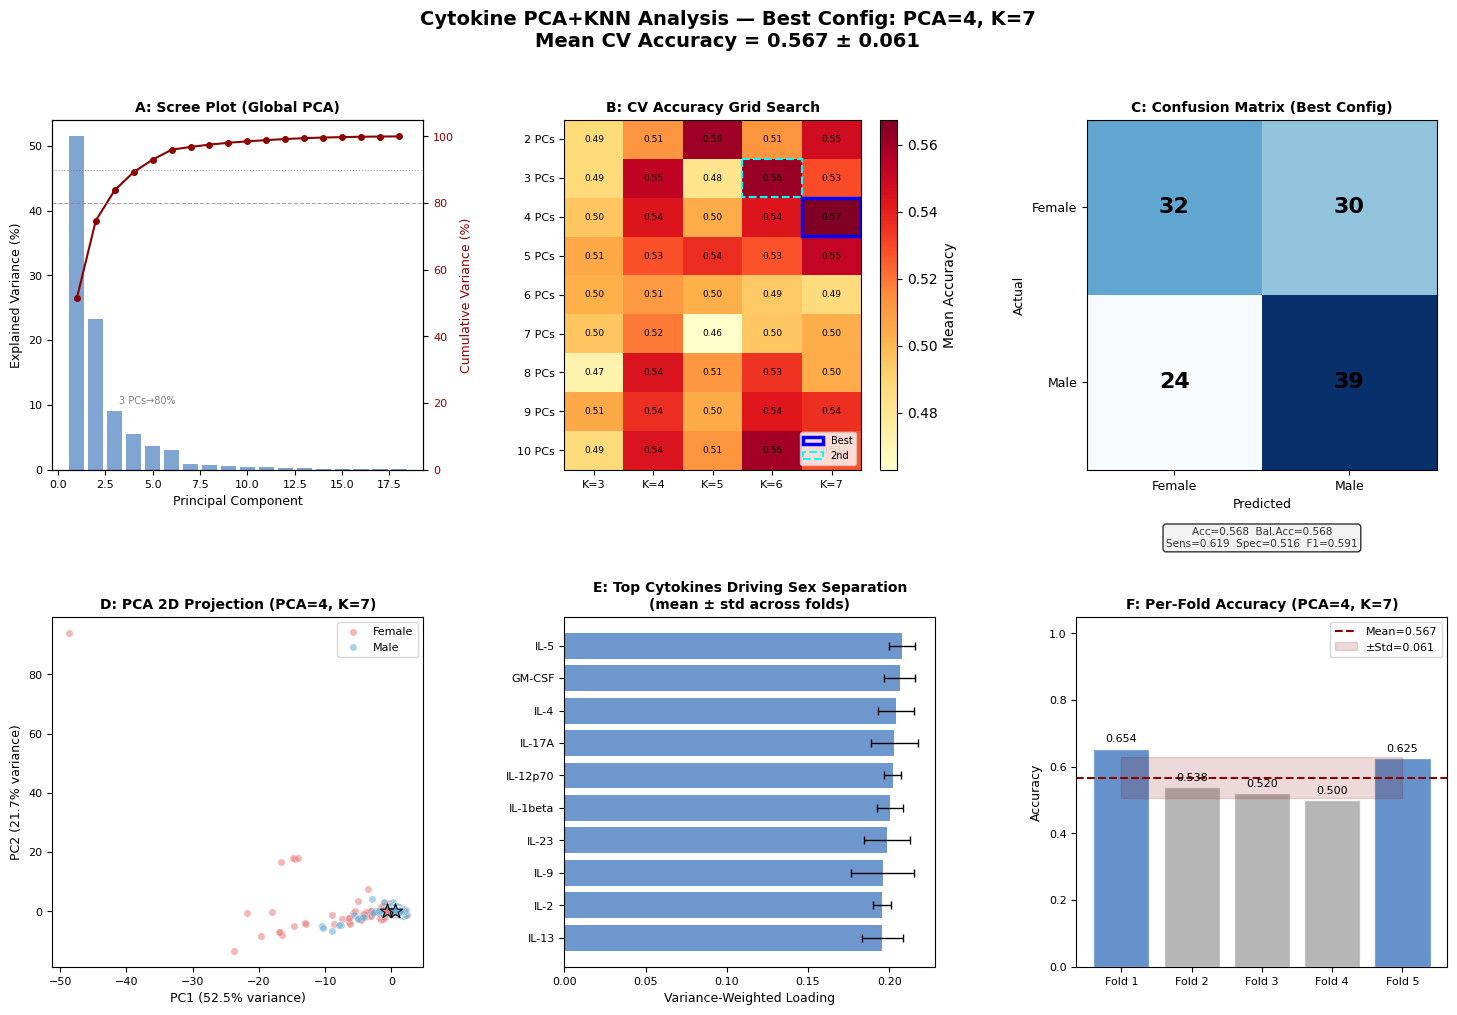

  Figure saved: cytokine_pca_knn_results.png
  Panel saved: panel_A_scree.png
  Panel saved: panel_b_heatmap.png
  Panel saved: panel_C_confusion.png
  Panel saved: panel_D_pca_scatter.png
  Panel saved: panel_E_importance.png
  Figures saved to: /Users/emmafranken/Desktop/School/CMU/machine learning/CytoKings/PCA+KNN/Outputs/figures



In [14]:
# ================================================================================
# SECTION 9: VISUALIZATION PANEL
# ================================================================================
# Figure layout (2 rows × 3 cols):
#   [A] Scree plot (global PCA)        [B] Grid search heatmap   [C] Confusion matrix
#   [D] PCA 2D scatter (best config)   [E] Feature importance    [F] Per-fold accuracy

fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    f"Cytokine PCA+KNN Analysis — Best Config: PCA={best_key[0]}, K={best_key[1]}\n"
    f"Mean CV Accuracy = {best_result['mean_acc']:.3f} ± {best_result['std_acc']:.3f}",
    fontsize=14, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# Color palette
COLOR_FEMALE = "#E87D7D"
COLOR_MALE   = "#6BAED6"
COLOR_BAR    = "#4A7FC1"

# ---- PANEL A: Scree Plot (Global PCA) ----------------------------------------
ax_a = fig.add_subplot(gs[0, 0])
x_pcs = range(1, len(explained_ratio_global) + 1)
ax_a.bar(x_pcs, explained_ratio_global * 100, color=COLOR_BAR, alpha=0.7, label="Per-PC")
ax_a2 = ax_a.twinx()
ax_a2.plot(x_pcs, cumulative_var_global * 100, color="darkred", marker="o",
           markersize=4, linewidth=1.5, label="Cumulative")
ax_a2.axhline(80, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax_a2.axhline(90, color="gray", linestyle=":",  linewidth=0.8, alpha=0.7)
ax_a2.set_ylabel("Cumulative Variance (%)", fontsize=9, color="darkred")
ax_a2.tick_params(axis='y', labelcolor="darkred", labelsize=8)
ax_a2.set_ylim(0, 105)
ax_a.set_xlabel("Principal Component", fontsize=9)
ax_a.set_ylabel("Explained Variance (%)", fontsize=9)
ax_a.set_title("A: Scree Plot (Global PCA)", fontsize=10, fontweight="bold")
ax_a.tick_params(labelsize=8)
ax_a.text(n_pcs_80 + 0.2, explained_ratio_global[n_pcs_80-1]*100 + 1,
          f"{n_pcs_80} PCs→80%", fontsize=7, color="gray")

# ---- PANEL B: Grid Search Heatmap -------------------------------------------
ax_b = fig.add_subplot(gs[0, 1])
heatmap_data = np.zeros((len(PCA_OPTIONS), len(K_OPTIONS)))
for i, n_pca in enumerate(PCA_OPTIONS):
    for j, k in enumerate(K_OPTIONS):
        heatmap_data[i, j] = results[(n_pca, k)]["mean_acc"]

im = ax_b.imshow(heatmap_data, cmap="YlOrRd", aspect="auto",
                 vmin=heatmap_data.min(), vmax=heatmap_data.max())
ax_b.set_xticks(range(len(K_OPTIONS)))
ax_b.set_xticklabels([f"K={k}" for k in K_OPTIONS], fontsize=8)
ax_b.set_yticks(range(len(PCA_OPTIONS)))
ax_b.set_yticklabels([f"{p} PCs" for p in PCA_OPTIONS], fontsize=8)
ax_b.set_title("B: CV Accuracy Grid Search", fontsize=10, fontweight="bold")
plt.colorbar(im, ax=ax_b, label="Mean Accuracy")

# Mark best and second-best
best_i   = PCA_OPTIONS.index(best_key[0])
best_j   = K_OPTIONS.index(best_key[1])
second_i = PCA_OPTIONS.index(second_key[0])
second_j = K_OPTIONS.index(second_key[1])
ax_b.add_patch(plt.Rectangle((best_j-0.5, best_i-0.5), 1, 1,
               fill=False, edgecolor="blue", linewidth=2.5, label="Best"))
ax_b.add_patch(plt.Rectangle((second_j-0.5, second_i-0.5), 1, 1,
               fill=False, edgecolor="cyan", linewidth=1.5, linestyle="--", label="2nd"))
ax_b.legend(loc="lower right", fontsize=7)

# Add accuracy values to cells
for i in range(len(PCA_OPTIONS)):
    for j in range(len(K_OPTIONS)):
        ax_b.text(j, i, f"{heatmap_data[i,j]:.2f}", ha="center", va="center",
                  fontsize=6.5, color="black")

# ---- PANEL C: Confusion Matrix -----------------------------------------------
ax_c = fig.add_subplot(gs[0, 2])
cm_display = cm_best.astype(float)
im_cm = ax_c.imshow(cm_display, cmap="Blues")
ax_c.set_xticks([0, 1])
ax_c.set_yticks([0, 1])
ax_c.set_xticklabels(["Female", "Male"], fontsize=9)
ax_c.set_yticklabels(["Female", "Male"], fontsize=9)
ax_c.set_xlabel("Predicted", fontsize=9)
ax_c.set_ylabel("Actual", fontsize=9)
ax_c.set_title("C: Confusion Matrix (Best Config)", fontsize=10, fontweight="bold")
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax_c.text(j, i, str(cm_best[i, j]), ha="center", va="center",
                fontsize=16, fontweight="bold",
                color="black")  # always black regardless of cell color

# Add metric summary below CM
metric_str = (f"Acc={metrics['Accuracy']:.3f}  "
              f"Bal.Acc={metrics['Balanced Accuracy']:.3f}\n"
              f"Sens={metrics['Sensitivity']:.3f}  "
              f"Spec={metrics['Specificity']:.3f}  "
              f"F1={metrics['F1 Score']:.3f}")
ax_c.text(0.5, -0.22, metric_str, transform=ax_c.transAxes,
          ha="center", fontsize=7.5, color="#333333",
          bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", alpha=0.8))

# ---- PANEL D: PCA 2D Scatter (Best Config, All Folds) -----------------------
ax_d = fig.add_subplot(gs[1, 0])

# Collect projections from the BEST config only — using PC1 and PC2
# Each fold gives slightly different projections; we pool all folds.
# PC axes may flip sign across folds (SVD sign ambiguity) — we align to fold 0.

ref_components = best_result["fold_loadings"][0]  # reference fold for sign alignment

X_proj_all = []
y_proj_all = []

for fold_idx, (X_tr_pca, X_te_pca, y_tr, y_te) in enumerate(best_result["fold_projections"]):
    # Sign-align this fold's components to reference fold
    components_this = best_result["fold_loadings"][fold_idx]
    signs = np.sign(np.sum(components_this[:2] * ref_components[:2], axis=1))
    X_tr_aligned = X_tr_pca.copy()
    X_te_aligned = X_te_pca.copy()
    X_tr_aligned[:, :2] *= signs[:2]
    X_te_aligned[:, :2] *= signs[:2]

    X_proj_all.append(np.vstack([X_tr_aligned[:, :2], X_te_aligned[:, :2]]))
    y_proj_all.append(np.concatenate([y_tr, y_te]))

X_proj_all = np.vstack(X_proj_all)
y_proj_all = np.concatenate(y_proj_all)

ax_d.scatter(X_proj_all[y_proj_all == 0, 0], X_proj_all[y_proj_all == 0, 1],
             c=COLOR_FEMALE, alpha=0.55, s=28, edgecolors="white", linewidths=0.4,
             label="Female")
ax_d.scatter(X_proj_all[y_proj_all == 1, 0], X_proj_all[y_proj_all == 1, 1],
             c=COLOR_MALE, alpha=0.55, s=28, edgecolors="white", linewidths=0.4,
             label="Male")

# Mean centroids
for label, color, name in [(0, COLOR_FEMALE, "F"), (1, COLOR_MALE, "M")]:
    cx = X_proj_all[y_proj_all == label, 0].mean()
    cy = X_proj_all[y_proj_all == label, 1].mean()
    ax_d.scatter(cx, cy, c=color, s=120, marker="*", edgecolors="black",
                 linewidths=0.8, zorder=5)

avg_var1 = np.mean([vr[0] for vr in best_result["fold_var_ratios"]])
avg_var2 = np.mean([vr[1] for vr in best_result["fold_var_ratios"]])
ax_d.set_xlabel(f"PC1 ({avg_var1*100:.1f}% variance)", fontsize=9)
ax_d.set_ylabel(f"PC2 ({avg_var2*100:.1f}% variance)", fontsize=9)
ax_d.set_title(f"D: PCA 2D Projection (PCA={best_key[0]}, K={best_key[1]})",
               fontsize=10, fontweight="bold")
ax_d.legend(fontsize=8)
ax_d.tick_params(labelsize=8)

# ---- PANEL E: Feature Importance (Top 10, variance-weighted) -----------------
ax_e = fig.add_subplot(gs[1, 1])
top_n = 10
top_idx      = ranking_idx[:top_n][::-1]
top_names    = [CYTO_COLS[i] for i in top_idx]
top_imp      = mean_importance[top_idx]
top_std      = std_importance[top_idx]

bars = ax_e.barh(top_names, top_imp, xerr=top_std,
                 color=COLOR_BAR, alpha=0.8, capsize=3,
                 error_kw={"linewidth": 1, "capthick": 1})
ax_e.set_xlabel("Variance-Weighted Loading", fontsize=9)
ax_e.set_title("E: Top Cytokines Driving Sex Separation\n(mean ± std across folds)",
               fontsize=10, fontweight="bold")
ax_e.tick_params(labelsize=8)
ax_e.axvline(0, color="black", linewidth=0.5)

# ---- PANEL F: Per-Fold Accuracy (Best Config) --------------------------------
ax_f = fig.add_subplot(gs[1, 2])
fold_acc_vals = best_result["fold_accs"]
fold_labels   = [f"Fold {i+1}" for i in range(N_SPLITS)]

bar_colors = [COLOR_BAR if a >= best_result["mean_acc"] else "#AAAAAA"
              for a in fold_acc_vals]
ax_f.bar(fold_labels, fold_acc_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax_f.axhline(best_result["mean_acc"], color="darkred", linestyle="--",
             linewidth=1.5, label=f"Mean={best_result['mean_acc']:.3f}")
ax_f.fill_between(
    range(N_SPLITS),
    best_result["mean_acc"] - best_result["std_acc"],
    best_result["mean_acc"] + best_result["std_acc"],
    alpha=0.15, color="darkred", label=f"±Std={best_result['std_acc']:.3f}"
)
ax_f.set_ylabel("Accuracy", fontsize=9)
ax_f.set_title(f"F: Per-Fold Accuracy (PCA={best_key[0]}, K={best_key[1]})",
               fontsize=10, fontweight="bold")
ax_f.legend(fontsize=8)
ax_f.set_ylim(0, 1.05)
ax_f.tick_params(labelsize=8)
for i, v in enumerate(fold_acc_vals):
    ax_f.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

plt.savefig(FIGURES_PATH / "cytokine_pca_knn_results.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("  Figure saved: cytokine_pca_knn_results.png")

fig.canvas.draw()
save_panel(fig, ax_a,  "panel_A_scree.png")
save_panel(fig, ax_b,  "panel_b_heatmap.png")
save_panel(fig, ax_c,  "panel_C_confusion.png")
save_panel(fig, ax_d,  "panel_D_pca_scatter.png")
save_panel(fig, ax_e,  "panel_E_importance.png")
plt.close()

print("  Figures saved to:", FIGURES_PATH)
print()




In [ ]:
# ================================================================================
# SECTION 10: DATA EXPORT FOR DOWNSTREAM MODELS
# ================================================================================
# Handoff for teammates running XGBoost, SVM, Random Forest, etc.
#
# WHAT IS EXPORTED:
#   X_processed.npy     : Full dataset, standardized (fit on full X)
#                         Shape: (n_samples, n_features)
#                         NOTE: For rigorous CV in next models, teammates should
#                         re-standardize within their own CV folds.
#
#   X_pca_best.npy      : Full dataset projected to best PCA config
#                         Shape: (n_samples, best_n_pca)
#                         Ready for direct use as input features.
#
#   y_labels.npy        : Binary sex labels (1=Male, 0=Female)
#
#   pca_components.npy  : PCA projection matrix fit on full dataset
#                         Shape: (best_n_pca, n_features)
#
#   results_summary.csv : All (PCA, K) combos ranked by accuracy
#   feature_importance.csv: Cytokine importance for model interpretability

print("=" * 65)
print("SECTION 10: EXPORTING DATA FOR DOWNSTREAM MODELS")
print("=" * 65)

# Standardize full dataset
X_proc_mean = X_raw.mean(axis=0)
X_proc_std  = X_raw.std(axis=0)
X_proc_std[X_proc_std == 0] = 1
X_processed = (X_raw - X_proc_mean) / X_proc_std

# PCA on full processed dataset using best n_pca
best_n_pca     = best_key[0]
best_k         = best_key[1]
components_full, var_ratio_full, mean_full = pca_fit(X_processed, best_n_pca)
X_pca_best     = pca_transform(X_processed, mean_full, components_full)

# Save arrays
np.save(OUTPUT_PATH / "X_processed.npy",     X_processed)
np.save(OUTPUT_PATH / "X_pca_best.npy",      X_pca_best)
np.save(OUTPUT_PATH / "y_labels.npy",        y)
np.save(OUTPUT_PATH / "pca_components.npy",  components_full)

print(f"  X_processed.npy     : shape {X_processed.shape}")
print(f"  X_pca_best.npy      : shape {X_pca_best.shape}  (best config: {best_n_pca} PCs)")
print(f"  y_labels.npy        : shape {y.shape}  — 1=Male, 0=Female")
print(f"  pca_components.npy  : shape {components_full.shape}")
print(f"  results_summary.csv : all {len(results)} combos ranked")
print(f"  feature_importance.csv: {len(CYTO_COLS)} cytokines ranked")
print(f"  fcm_vs_knn_comparison.csv: FCM vs KNN across k=2..6")

print()
print("=" * 65)
print("PIPELINE COMPLETE")
print("=" * 65)
print(f"  Best config  : PCA={best_n_pca}, K={best_k}")
print(f"  Accuracy     : {metrics['Accuracy']:.4f}")
print(f"  Balanced Acc : {metrics['Balanced Accuracy']:.4f}")
print(f"  Sensitivity  : {metrics['Sensitivity']:.4f}  (Male detection rate)")
print(f"  Specificity  : {metrics['Specificity']:.4f}  (Female detection rate)")
print(f"  F1 Score     : {metrics['F1 Score']:.4f}")
print(f"  Top cytokine : {importance_df.iloc[0]['Cytokine']} "
      f"(importance={importance_df.iloc[0]['Importance']:.4f})")
print()
print("  SOFT CLUSTERING SUMMARY:")
print(f"  Best FCM (Global PCA) : k={best_fcm_k_global} | "
      f"Acc={best_fcm_global['accuracy']:.4f} | "
      f"FPC={best_fcm_global['fpc']:.4f}")
print(f"  Best FCM (CV PCA)     : k={best_fcm_k_cv} | "
      f"Acc={best_fcm_cv['accuracy']:.4f} | "
      f"FPC={best_fcm_cv['fpc']:.4f}")
print(f"  Best overall          : {best_overall[0]} "
      f"(Acc={best_overall[1]:.4f})")
print()

# Runtime
notebook_end = time.time()
elapsed      = notebook_end - notebook_start
mins, secs   = divmod(int(elapsed), 60)
print(f"  Total runtime: {mins}m {secs}s")
print("=" * 65)

SECTION 10: EXPORTING DATA FOR DOWNSTREAM MODELS
  X_processed.npy     : shape (125, 18)
  X_pca_best.npy      : shape (125, 4)  (best config: 4 PCs)
  y_labels.npy        : shape (125,)  — 1=Male, 0=Female
  pca_components.npy  : shape (4, 18)
  results_summary.csv : all 45 combos ranked
  feature_importance.csv: 18 cytokines ranked
  fcm_vs_knn_comparison.csv: FCM vs KNN across k=2..6

PIPELINE COMPLETE
  Best config  : PCA=4, K=7
  Accuracy     : 0.5680
  Balanced Acc : 0.5676
  Sensitivity  : 0.6190  (Male detection rate)
  Specificity  : 0.5161  (Female detection rate)
  F1 Score     : 0.5909
  Top cytokine : IL-5 (importance=0.2080)

  SOFT CLUSTERING SUMMARY:
  Best FCM (Global PCA) : k=4 | Acc=0.5520 | FPC=0.7948
  Best FCM (CV PCA)     : k=6 | Acc=0.5760 | FPC=0.6309
  Best overall          : FCM CV k=6 (Acc=0.5760)

  Total runtime: 0m 5s
